In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### **Chapeter 2.4 - Problem 1**


a) a flexible model would yield a better result due to the surplus of data and minimal predictors.

b) a non-flexible model would also be better for this situation, the inbalance of perameters to data points could very likely lead to overfitting.

c) flexible, you need flexibility to capture a non-linear relationship

d) non-flexible, there is a lot of noise and a flexible model would overfit to that noise.

### **Chapeter 2.4 - Problem 2**

a) regression, n = 500, p = 3

b) classification, n = 20, p = 15

c) regression, n = 52, p = 4

### **Chapeter 2.4 - Problem 3**

   Flexibility    Bias^2  Variance  Training Error  Test Error  Bayes Error
0      0.00000  5.000000  0.200000        1.000000    5.200000          0.6
1      0.10101  4.753746  0.206849        0.934877    4.960594          0.6
2      0.20202  4.519620  0.213932        0.873995    4.733551          0.6
3      0.30303  4.297024  0.221258        0.817078    4.518282          0.6
4      0.40404  4.085392  0.228834        0.763868    4.314226          0.6


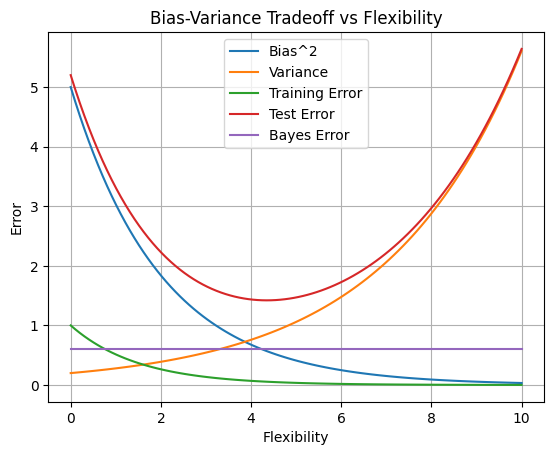

In [4]:
flexibility = np.linspace(0, 10, 100)


bias2 = np.exp(-flexibility / 2) * 5
variance = np.exp(flexibility / 3) / 5
training_error = np.exp(-flexibility / 1.5)
test_error = bias2 + variance
bayes_error = np.ones_like(flexibility) * 0.6



df = pd.DataFrame({
    "Flexibility": flexibility,
    "Bias^2": bias2,
    "Variance": variance,
    "Training Error": training_error,
    "Test Error": test_error,
    "Bayes Error": bayes_error
})

print(df.head())


plt.figure()

plt.plot(df["Flexibility"], df["Bias^2"], label="Bias^2")
plt.plot(df["Flexibility"], df["Variance"], label="Variance")
plt.plot(df["Flexibility"], df["Training Error"], label="Training Error")
plt.plot(df["Flexibility"], df["Test Error"], label="Test Error")
plt.plot(df["Flexibility"], df["Bayes Error"], label="Bayes Error")

plt.xlabel("Flexibility")
plt.ylabel("Error")

plt.legend()
plt.grid(True)

plt.show()

bias^2: More flexibility, model can match true structure better, bias falls

variance: More flexibility, model is more sensitive to the specific training sample, variance rises

training error: always improves with flexibility because you can fit the training data more closely

test error balances both: initially bias reduction helps, but eventually variance takes over

bayes error: the noise you can’t remove even with the true model

### **Chapeter 2.4 - Problem 7**

In [5]:
from collections import Counter

X = np.array([
    [ 0, 3, 0],   # Obs 1
    [ 2, 0, 0],   # Obs 2
    [ 0, 1, 3],   # Obs 3
    [ 0, 1, 2],   # Obs 4
    [-1, 0, 1],   # Obs 5
    [ 1, 1, 1],   # Obs 6
], dtype=float)

labels = np.array([
    "Red",   # Obs 1
    "Red",   # Obs 2
    "Red",   # Obs 3
    "Green", # Obs 4
    "Green", # Obs 5
    "Red",   # Obs 6
])

x_test = np.array([0, 0, 0], dtype=float)

def euclidean_distances(X, x):
    # distance from each row in X to x
    return np.sqrt(((X - x) ** 2).sum(axis=1))

dists = euclidean_distances(X, x_test)
order = np.argsort(dists)

print("Distances to test point (0,0,0):")
for rank, i in enumerate(order, start=1):
    print(f"{rank}. Obs {i+1}: point={X[i].astype(int)}, label={labels[i]}, dist={dists[i]:.3f}")


Distances to test point (0,0,0):
1. Obs 5: point=[-1  0  1], label=Green, dist=1.414
2. Obs 6: point=[1 1 1], label=Red, dist=1.732
3. Obs 2: point=[2 0 0], label=Red, dist=2.000
4. Obs 4: point=[0 1 2], label=Green, dist=2.236
5. Obs 1: point=[0 3 0], label=Red, dist=3.000
6. Obs 3: point=[0 1 3], label=Red, dist=3.162


b) k = 1 is obs 5, green wins

c) k = 3 is obs 5, obs 6, and obs 2, red wins

d)small k means is better, less noise is captured